# Step 1: Importing  

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

# Step 2: Read the file 

In [8]:
df = pd.read_csv("heart_diseases.csv")
df

,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# Step 3: Preprocessing

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
df.tail()

In [5]:
df.sample(10)

,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
62,62,45,M,ASY,140,224,0,Normal,144,N,0.0,Up,0
481,481,69,M,NAP,140,0,1,ST,118,N,2.5,Down,1
398,398,52,M,ASY,165,0,1,Normal,122,Y,1.0,Up,1
472,472,53,M,ASY,154,0,1,ST,140,Y,1.5,Flat,1
859,859,51,F,NAP,140,308,0,LVH,142,N,1.5,Up,0
212,212,56,M,NAP,130,276,0,Normal,128,Y,1.0,Up,0
820,820,52,M,TA,152,298,1,Normal,178,N,1.2,Flat,0
512,512,35,M,NAP,123,161,0,ST,153,N,-0.1,Up,0
898,898,35,M,ATA,122,192,0,Normal,174,N,0.0,Up,0
839,839,35,F,ASY,138,183,0,Normal,182,N,1.4,Up,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      918 non-null    int64  
 1   Age             918 non-null    int64  
 2   Sex             918 non-null    str    
 3   ChestPainType   918 non-null    str    
 4   RestingBP       918 non-null    int64  
 5   Cholesterol     918 non-null    int64  
 6   FastingBS       918 non-null    int64  
 7   RestingECG      918 non-null    str    
 8   MaxHR           918 non-null    int64  
 9   ExerciseAngina  918 non-null    str    
 10  Oldpeak         918 non-null    float64
 11  ST_Slope        918 non-null    str    
 12  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 104.7 KB


In [9]:
df.isna().sum()

Unnamed: 0        0
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,Unnamed: 0,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,458.500000,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,265.148072,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,0.000000,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,229.250000,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,458.500000,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,687.750000,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,917.000000,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
df.describe(include="O")

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


# Step 4: Data Cleaning

In [13]:
df=df.drop(columns="Unnamed: 0")

In [14]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# Step 5: EDA

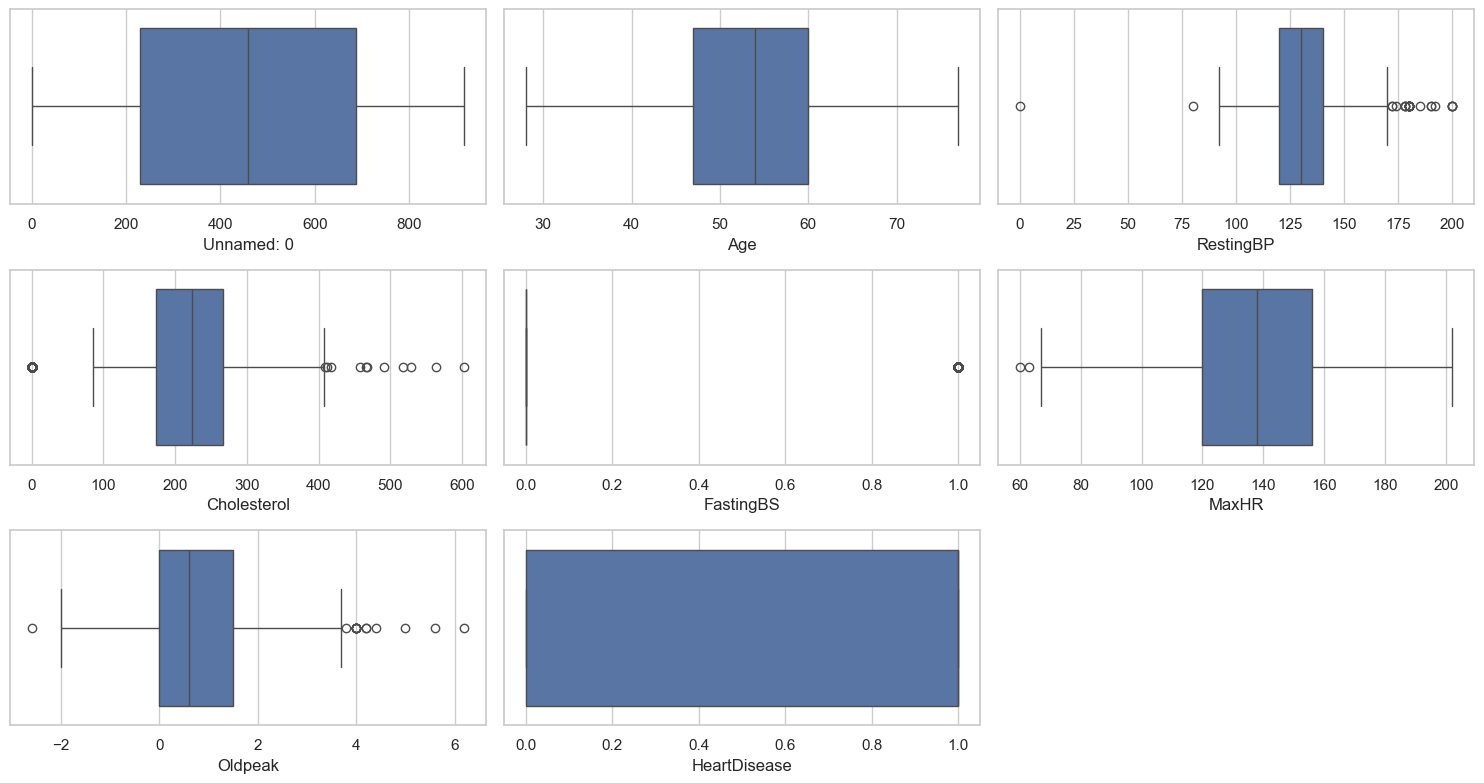

In [24]:

plt.figure(figsize=(15,8))
c=1
for i in df.describe().columns:
    plt.subplot(3,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

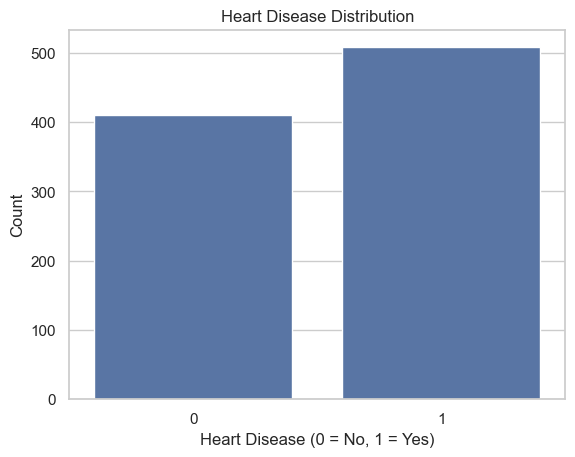

In [21]:
plt.figure()
sns.countplot(x="HeartDisease", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

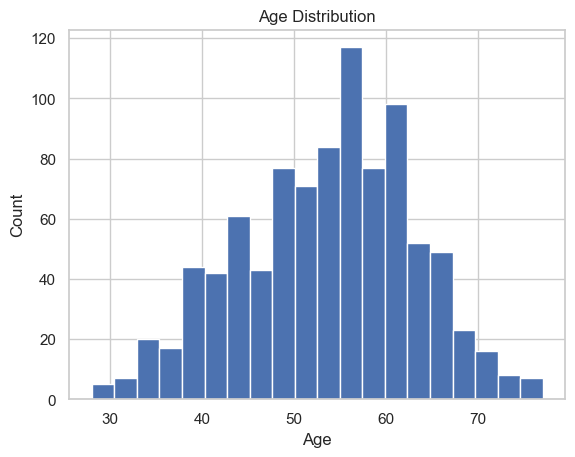

In [22]:
plt.figure()
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

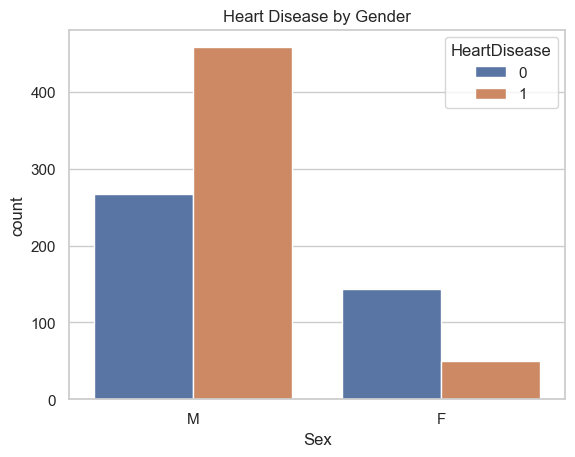

In [23]:
plt.figure()
sns.countplot(x="Sex", hue="HeartDisease", data=df)
plt.title("Heart Disease by Gender")
plt.show()

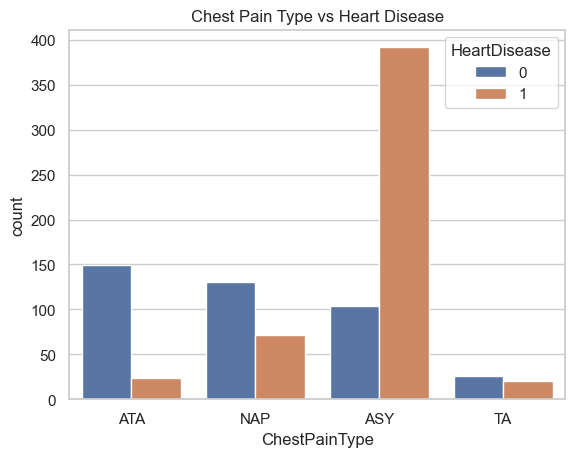

In [25]:
plt.figure()
sns.countplot(x="ChestPainType", hue="HeartDisease", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

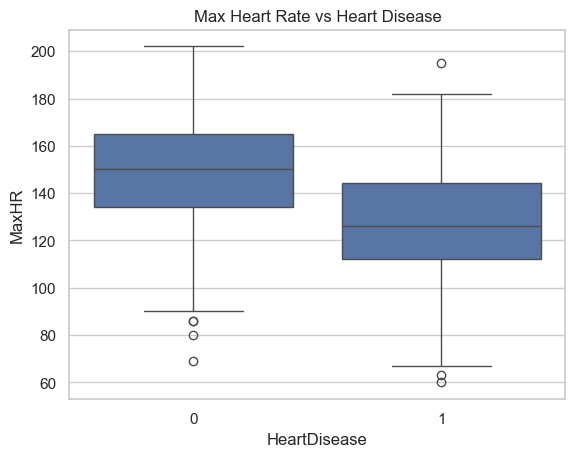

In [26]:
plt.figure()
sns.boxplot(x="HeartDisease", y="MaxHR", data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

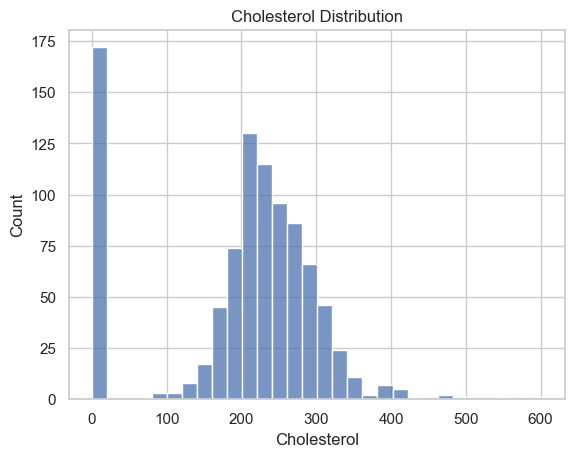

In [27]:
plt.figure()
sns.histplot(df["Cholesterol"], bins=30)
plt.title("Cholesterol Distribution")
plt.show()

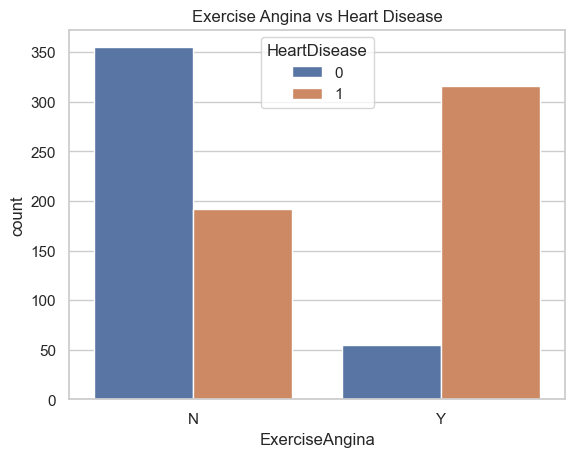

In [28]:
plt.figure()
sns.countplot(x="ExerciseAngina", hue="HeartDisease", data=df)
plt.title("Exercise Angina vs Heart Disease")
plt.show()

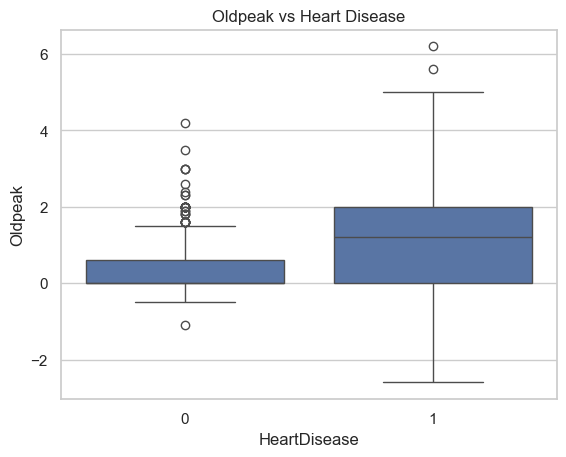

In [29]:
plt.figure()
sns.boxplot(x="HeartDisease", y="Oldpeak", data=df)
plt.title("Oldpeak vs Heart Disease")
plt.show()

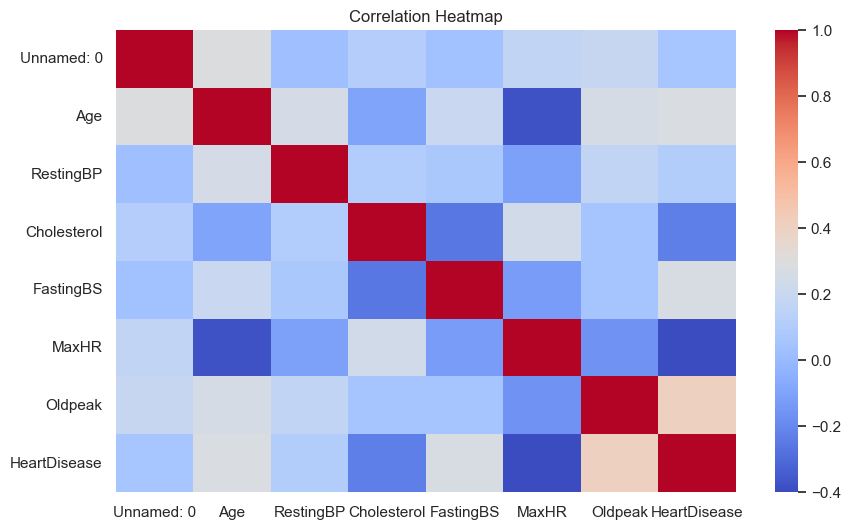

In [30]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Step 6: Feature Engeneering

In [26]:
df.describe(include="O").columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [27]:
df.select_dtypes("object").columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [29]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
for i in df.select_dtypes("object").columns:
    df[i]=label.fit_transform(df[i])

In [30]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1,1
914,68,1,0,144,193,1,1,141,0,3.4,1,1
915,57,1,0,130,131,0,1,115,1,1.2,1,1
916,57,0,1,130,236,0,0,174,0,0.0,1,1


# Step 7: Slit the data into input or target variable

In [31]:
x = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

In [32]:
from sklearn.model_selection import train_test_split as tts

In [33]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.3)

In [34]:
# x_train,x_test,y_train,y_test=tts(x,y,test_size=0.3,random_state=42)

In [35]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(642, 11)
(276, 11)
(642,)
(276,)


# Step 8: Train the model

In [36]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()

In [38]:
model=LR.fit(x_train,y_train)
model

LogisticRegression()

In [39]:
pred=model.predict(x_test)
pred

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1], dtype=int64)

In [40]:
y_test

756    0
633    0
628    1
667    0
795    0
      ..
897    1
113    0
892    0
315    1
784    1
Name: HeartDisease, Length: 276, dtype: int64

# Step 9: Evluate the model

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
score = accuracy_score(pred,y_test)

In [43]:
score

0.8297101449275363